In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
print("Libraries loaded!")


Libraries loaded!


In [11]:
df = pd.read_csv('../data/Road.csv')  # apna actual filename daalo
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (12316, 32)

Columns: ['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']


In [12]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [13]:
print("Missing values:\n")
print(df.isnull().sum())

Missing values:

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_cas

In [14]:
# High missing (>30%) — drop karo
df.drop(columns=['Defect_of_vehicle', 'Service_year_of_vehicle'], inplace=True)

# Baaki missing — mode se fill karo (categorical data hai)
cols_to_fill = ['Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
                'Type_of_vehicle', 'Owner_of_vehicle', 'Area_accident_occured',
                'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction',
                'Road_surface_type', 'Type_of_collision', 'Vehicle_movement']

for col in cols_to_fill:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum().sum(), "total nulls remaining")

Missing values after cleaning:
5833 total nulls remaining


C:\Users\omesh\AppData\Local\Temp\ipykernel_22884\10701010.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [15]:
print(df['Accident_severity'].value_counts())
print("\nPercentage:")
print(df['Accident_severity'].value_counts(normalize=True) * 100)

Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64

Percentage:
Accident_severity
Slight Injury     84.564794
Serious Injury    14.152322
Fatal injury       1.282884
Name: proportion, dtype: float64


In [16]:
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.hour
print(df['Hour'].value_counts().sort_index())

Hour
0      206
1      134
2       84
3       84
4       91
5       76
6      214
7      532
8      828
9      559
10     500
11     603
12     691
13     772
14     639
15     874
16     921
17    1228
18     956
19     708
20     604
21     401
22     402
23     209
Name: count, dtype: int64


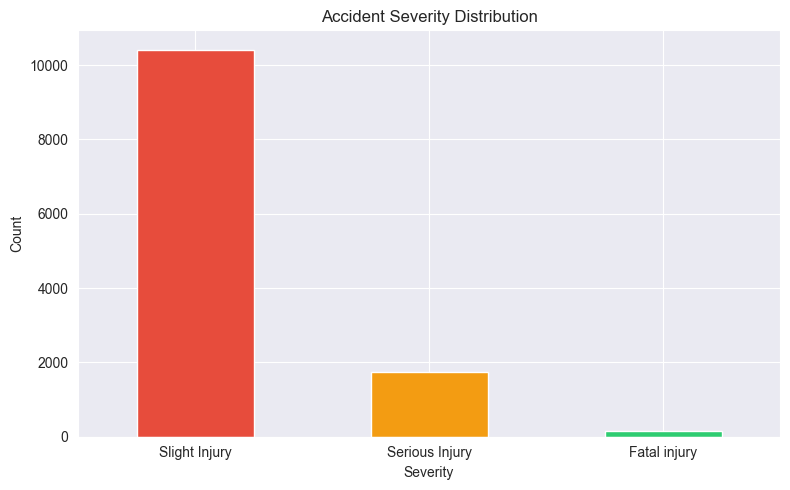

In [17]:
plt.figure(figsize=(8, 5))
df['Accident_severity'].value_counts().plot(kind='bar', color=['#e74c3c','#f39c12','#2ecc71'])
plt.title('Accident Severity Distribution')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

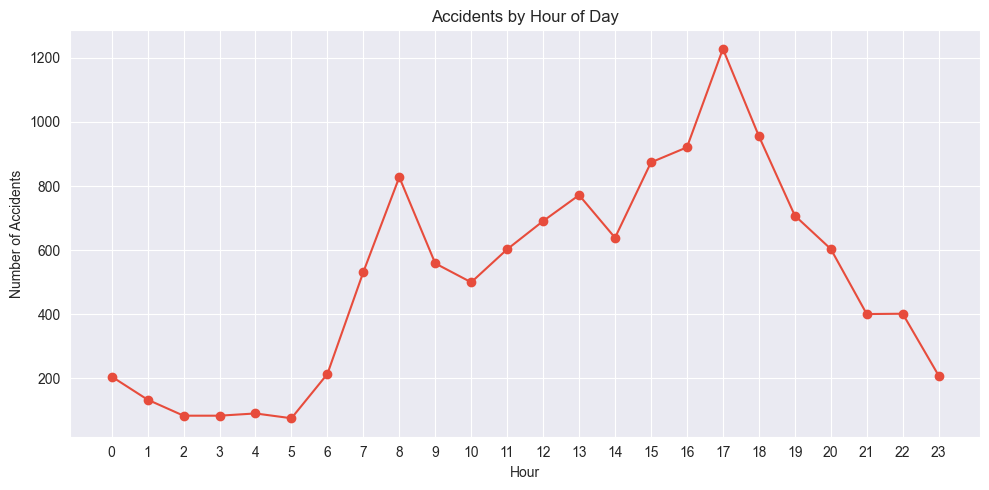

In [18]:
plt.figure(figsize=(10, 5))
df['Hour'].value_counts().sort_index().plot(kind='line', marker='o', color='#e74c3c')
plt.title('Accidents by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Accidents')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

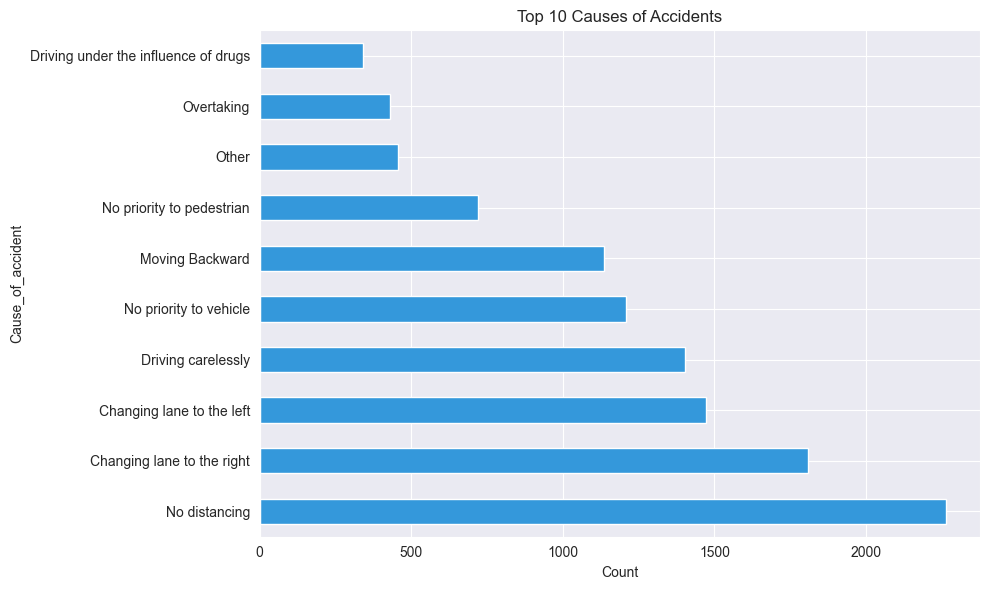

In [19]:
plt.figure(figsize=(10, 6))
df['Cause_of_accident'].value_counts().head(10).plot(kind='barh', color='#3498db')
plt.title('Top 10 Causes of Accidents')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

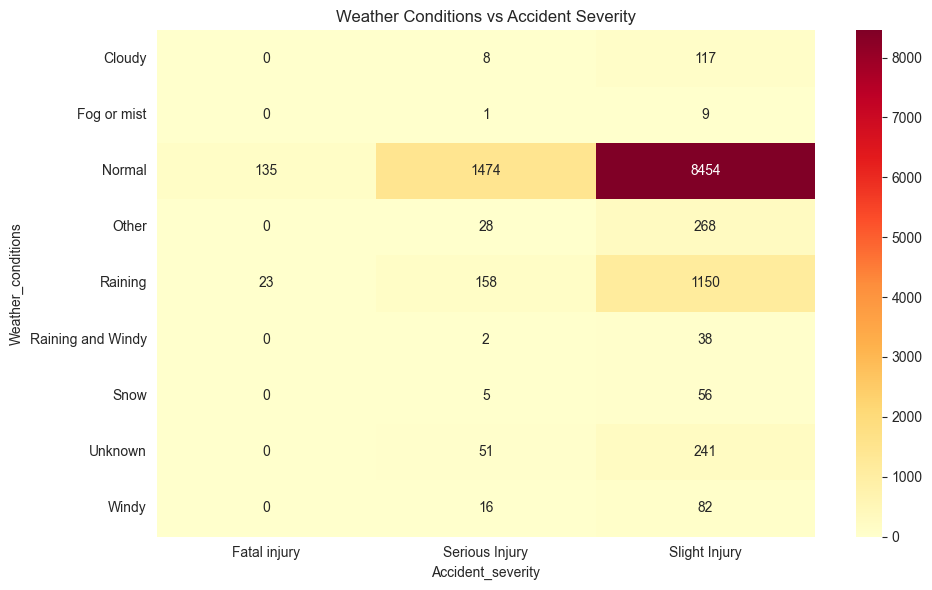

In [20]:
ct = pd.crosstab(df['Weather_conditions'], df['Accident_severity'])
plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Weather Conditions vs Accident Severity')
plt.tight_layout()
plt.show()

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode karo saare categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Encoding columns:", cat_cols)

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Encoding done!")
df.head()

Encoding columns: ['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']
Encoding done!


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Area_accident_occured,...,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,Hour
0,420,1,0,1,0,0,0,0,3,9,...,3,2,5,3,7,5,5,9,2,17
1,420,1,1,1,4,0,3,11,3,6,...,3,2,5,3,7,5,5,16,2,17
2,420,1,0,1,4,0,0,5,3,1,...,0,1,1,2,0,5,5,0,1,17
3,594,3,0,1,4,0,2,11,0,6,...,2,0,0,2,0,2,5,1,2,1
4,594,3,0,1,4,0,1,0,3,4,...,3,2,5,3,7,5,5,16,2,1


In [23]:
# Target: Accident_severity
# Features: baaki sab useful columns

X = df.drop(columns=['Accident_severity', 'Casualty_severity', 
                      'Casualty_class', 'Sex_of_casualty',
                      'Age_band_of_casualty', 'Work_of_casuality',
                      'Fitness_of_casuality', 'Pedestrian_movement'])

y = df['Accident_severity']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget classes:", y.unique())

Features shape: (12316, 23)
Target shape: (12316,)

Target classes: [2 1 0]


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (9852, 23)
Test size: (2464, 23)


In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1  # saare CPU cores use karega — fast training
)

rf_model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Accuracy: 84.7 %

Detailed Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       1.00      0.01      0.02       349
           2       0.85      1.00      0.92      2084

    accuracy                           0.85      2464
   macro avg       0.62      0.34      0.31      2464
weighted avg       0.86      0.85      0.78      2464



d:\Livstream\accident_hotspot\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Livstream\accident_hotspot\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Livstream\accident_hotspot\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

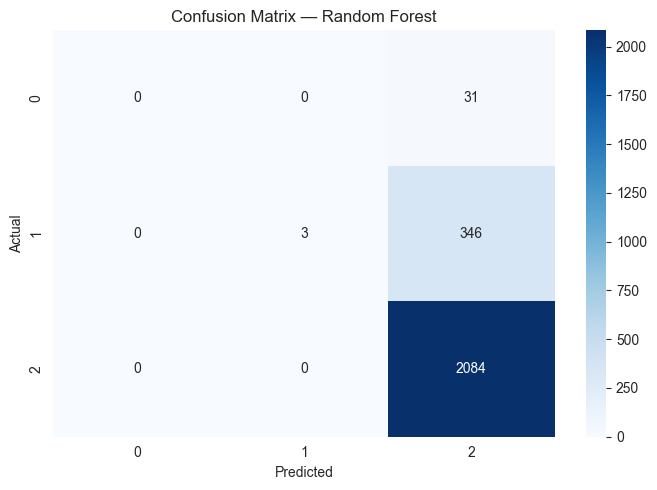

In [27]:
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

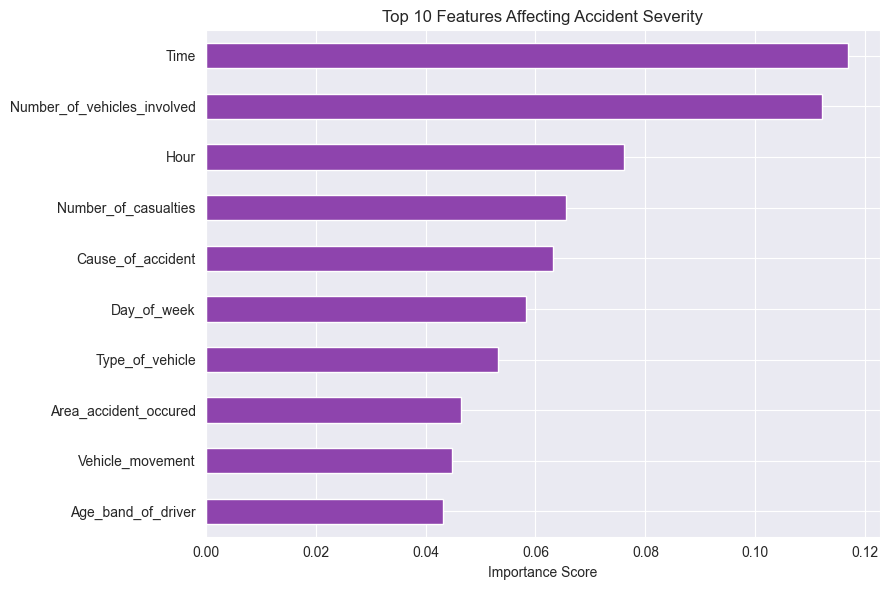

In [28]:
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 6))
feat_imp.plot(kind='barh', color='#8e44ad')
plt.title('Top 10 Features Affecting Accident Severity')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [29]:
import joblib
joblib.dump(rf_model, '../models/accident_model.pkl')
joblib.dump(list(X.columns), '../models/feature_columns.pkl')
print("Model saved!")

Model saved!


In [30]:
# Decode karne ke liye original data reload karte hain sirf area column ke liye
df_orig = pd.read_csv('../data/Road.csv')  # apna filename daalo

area_counts = df_orig['Area_accident_occured'].value_counts().reset_index()
area_counts.columns = ['Area', 'Accident_Count']
print(area_counts.head(10))

                   Area  Accident_Count
0                 Other            3819
1          Office areas            3451
2     Residential areas            2060
3          Church areas            1060
4      Industrial areas             456
5          School areas             415
6    Recreational areas             327
7   Outside rural areas             218
8        Hospital areas             121
9          Market areas              63


In [31]:
# Har area ko ek coordinate denge (Ethiopia ke major zones — dataset Ethiopian hai)
area_coords = {
    'Other': (9.0, 38.7),
    'Office areas': (9.02, 38.75),
    'Residential areas': (8.98, 38.68),
    'Church areas': (9.05, 38.72),
    'Industrial areas': (8.95, 38.65),
    'School areas': (9.01, 38.80),
    'Recreational areas': (9.08, 38.78),
    'Outside Addis Ababa': (8.50, 38.20),
    'Hospital areas': (9.03, 38.71),
    'Market areas': (9.00, 38.74),
    'Rural village areas': (8.70, 38.50),
    'Unknown': (9.0, 38.7)
}

# Map karo
area_counts['lat'] = area_counts['Area'].map(
    lambda x: area_coords.get(x, (9.0, 38.7))[0]
)
area_counts['lng'] = area_counts['Area'].map(
    lambda x: area_coords.get(x, (9.0, 38.7))[1]
)

print(area_counts)

                               Area  Accident_Count   lat    lng
0                             Other            3819  9.00  38.70
1                      Office areas            3451  9.02  38.75
2                 Residential areas            2060  8.98  38.68
3                      Church areas            1060  9.00  38.70
4                  Industrial areas             456  9.00  38.70
5                      School areas             415  9.01  38.80
6                Recreational areas             327  9.00  38.70
7               Outside rural areas             218  9.00  38.70
8                    Hospital areas             121  9.00  38.70
9                      Market areas              63  9.00  38.70
10              Rural village areas              44  8.70  38.50
11                          Unknown              22  9.00  38.70
12  Rural village areasOffice areas              20  9.00  38.70
13               Recreational areas               1  9.08  38.78


In [33]:
import folium
from folium.plugins import HeatMap, MarkerCluster

# Base map
accident_map = folium.Map(location=[9.0, 38.7], zoom_start=12)

# Heatmap data prepare karo
heat_data = []
for _, row in area_counts.iterrows():
    for _ in range(row['Accident_Count']):  # count ke hisaab se weight
        heat_data.append([
            row['lat'] + np.random.uniform(-0.01, 0.01),  # slight scatter
            row['lng'] + np.random.uniform(-0.01, 0.01)
        ])

# Heatmap layer add karo
HeatMap(heat_data, radius=25, blur=15, min_opacity=0.4).add_to(accident_map)

# Marker cluster add karo
marker_cluster = MarkerCluster().add_to(accident_map)

for _, row in area_counts.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=max(5, row['Accident_Count'] / 50),
        color='red',
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{row['Area']}</b><br>Accidents: {row['Accident_Count']}",
            max_width=200
        )
    ).add_to(marker_cluster)

# Save karo
accident_map.save('../data/hotspot_map.html')
print("Map saved! Open hotspot_map.html in browser")

Map saved! Open hotspot_map.html in browser


In [34]:
import webbrowser
import os

map_path = os.path.abspath('../data/hotspot_map.html')
webbrowser.open('file://' + map_path)
print("Map opening in browser...")

Map opening in browser...
